In [1]:
!pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/$CUDA_VERSION/torch$TORCH_VERSION/index.htmlz

Looking in links: https://dl.fbaipublicfiles.com/detectron2/wheels//torch/index.htmlz


In [2]:
import torch
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print(torch.__version__)

1.10.0


In [3]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
import matplotlib.pyplot as plt
# from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

class MyVisualizer(Visualizer):
    def _jitter(self, color):
        return color

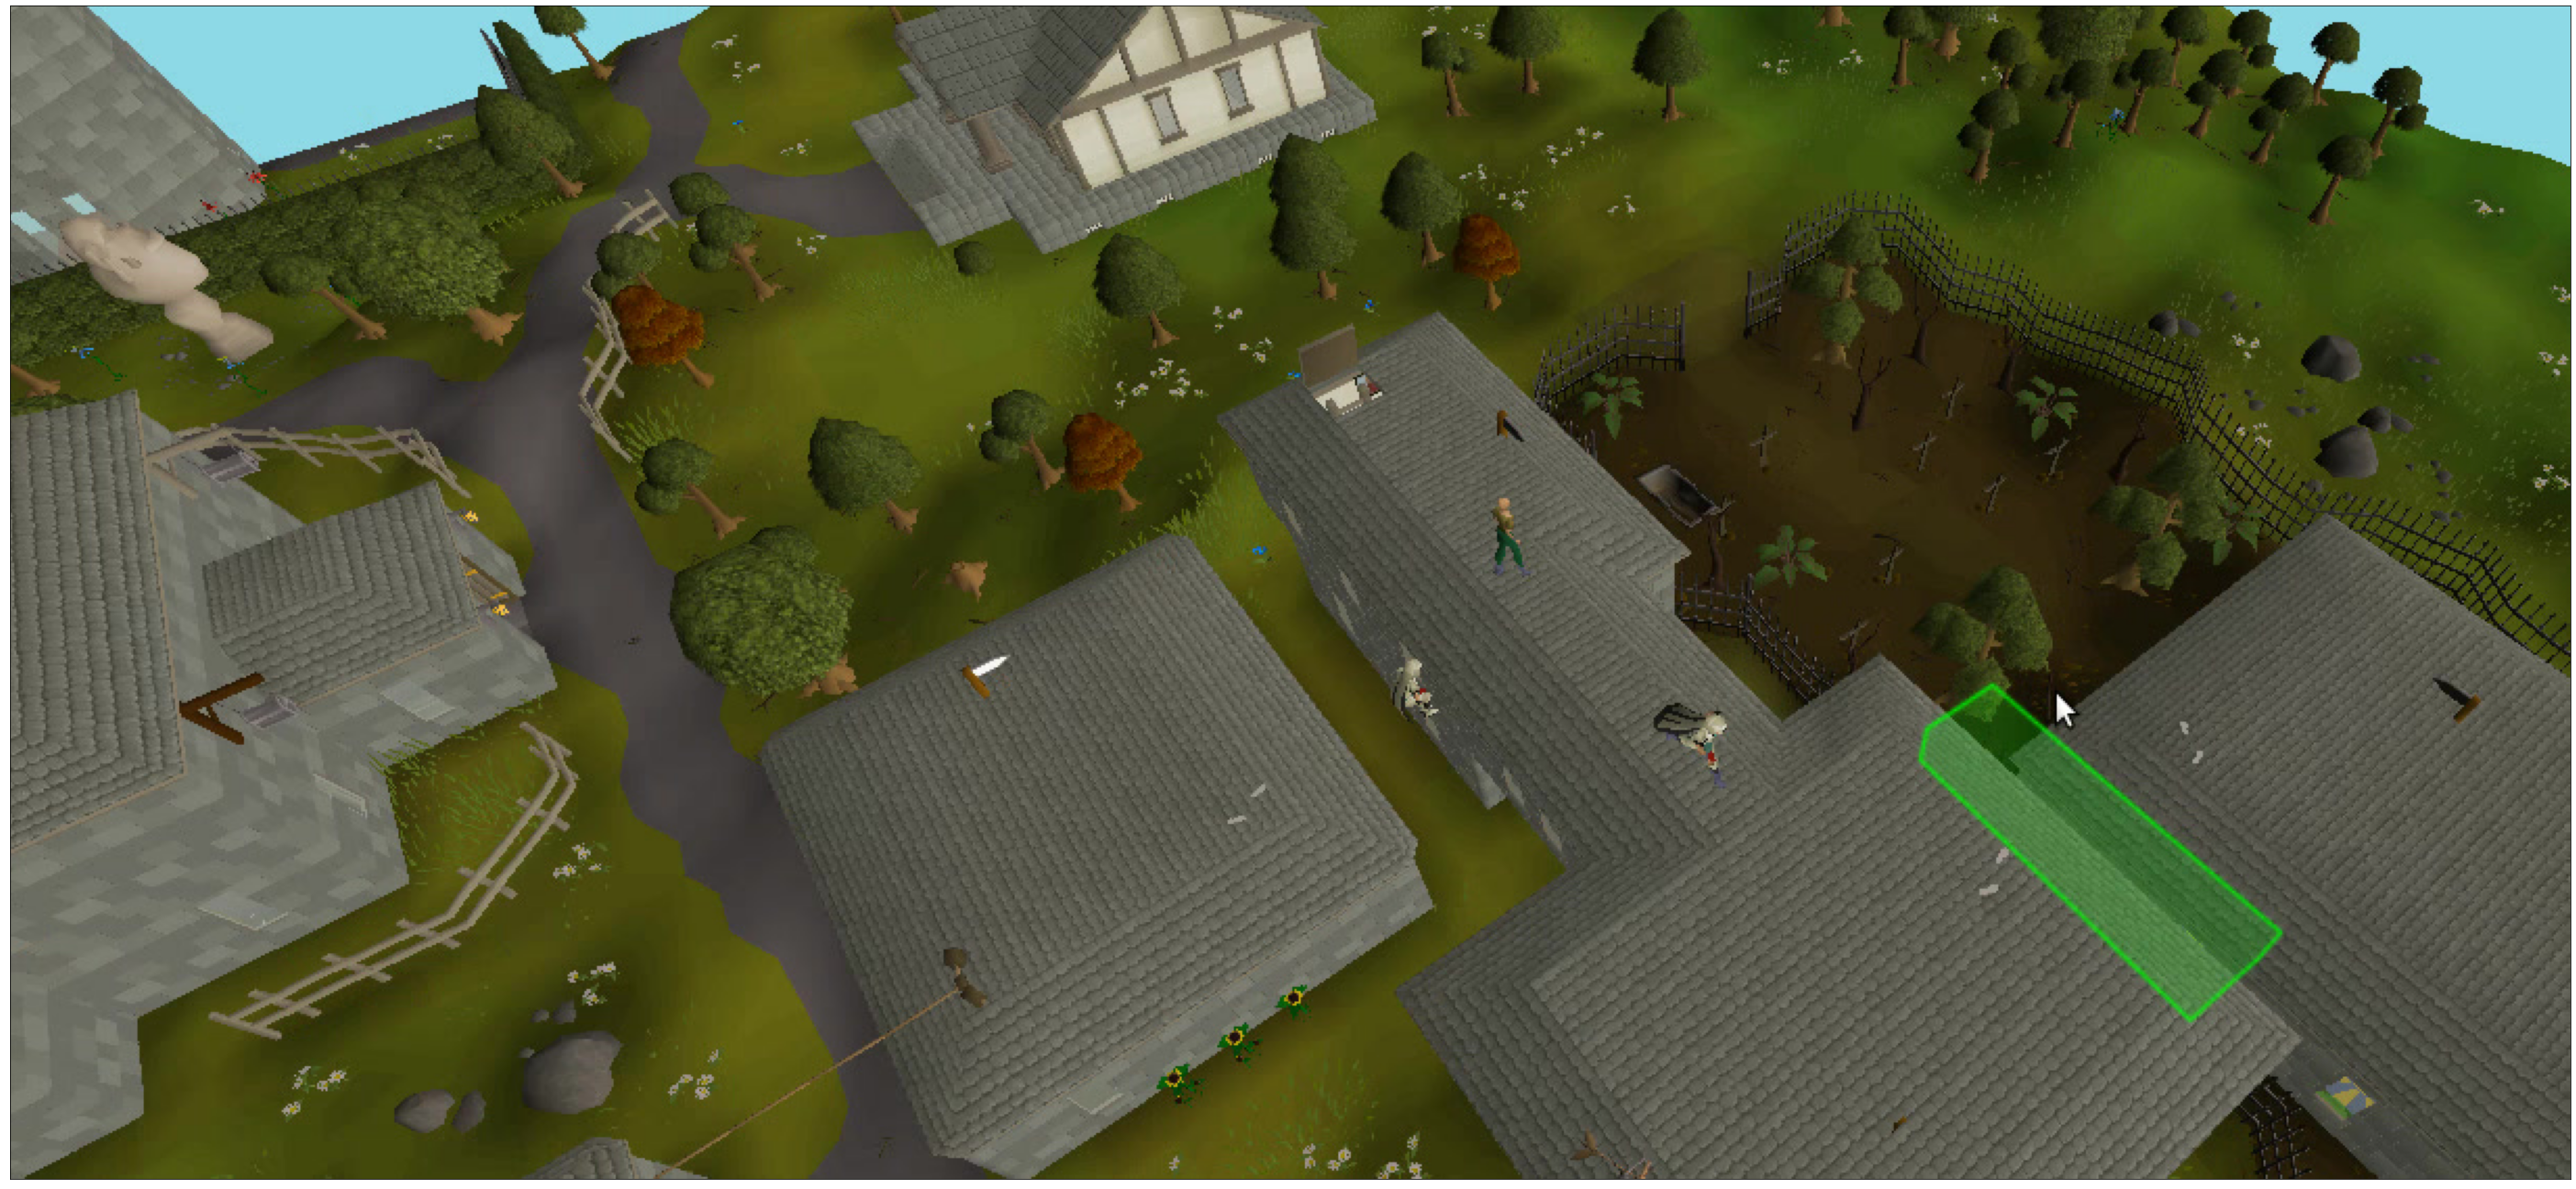

In [5]:
# read a test image
img = cv2.imread("./agility_data/video_frames/ezgif-frame-003.jpg", 1)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Converts from one colour space to the other

plt.figure(figsize=(50,50))
plt.imshow(img)
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
plt.show()

In [6]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

In [7]:
cfg.MODEL.WEIGHTS = os.path.join("./", "agility_model.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (3, 1024) in the checkpoint but (81, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (3,) in the checkpoint but (81,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (8, 1024) in the checkpoint but (320, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (8,) in the checkpoint but (320,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (2, 256, 1, 1) in the checkpoint but (80, 256, 1, 1) in

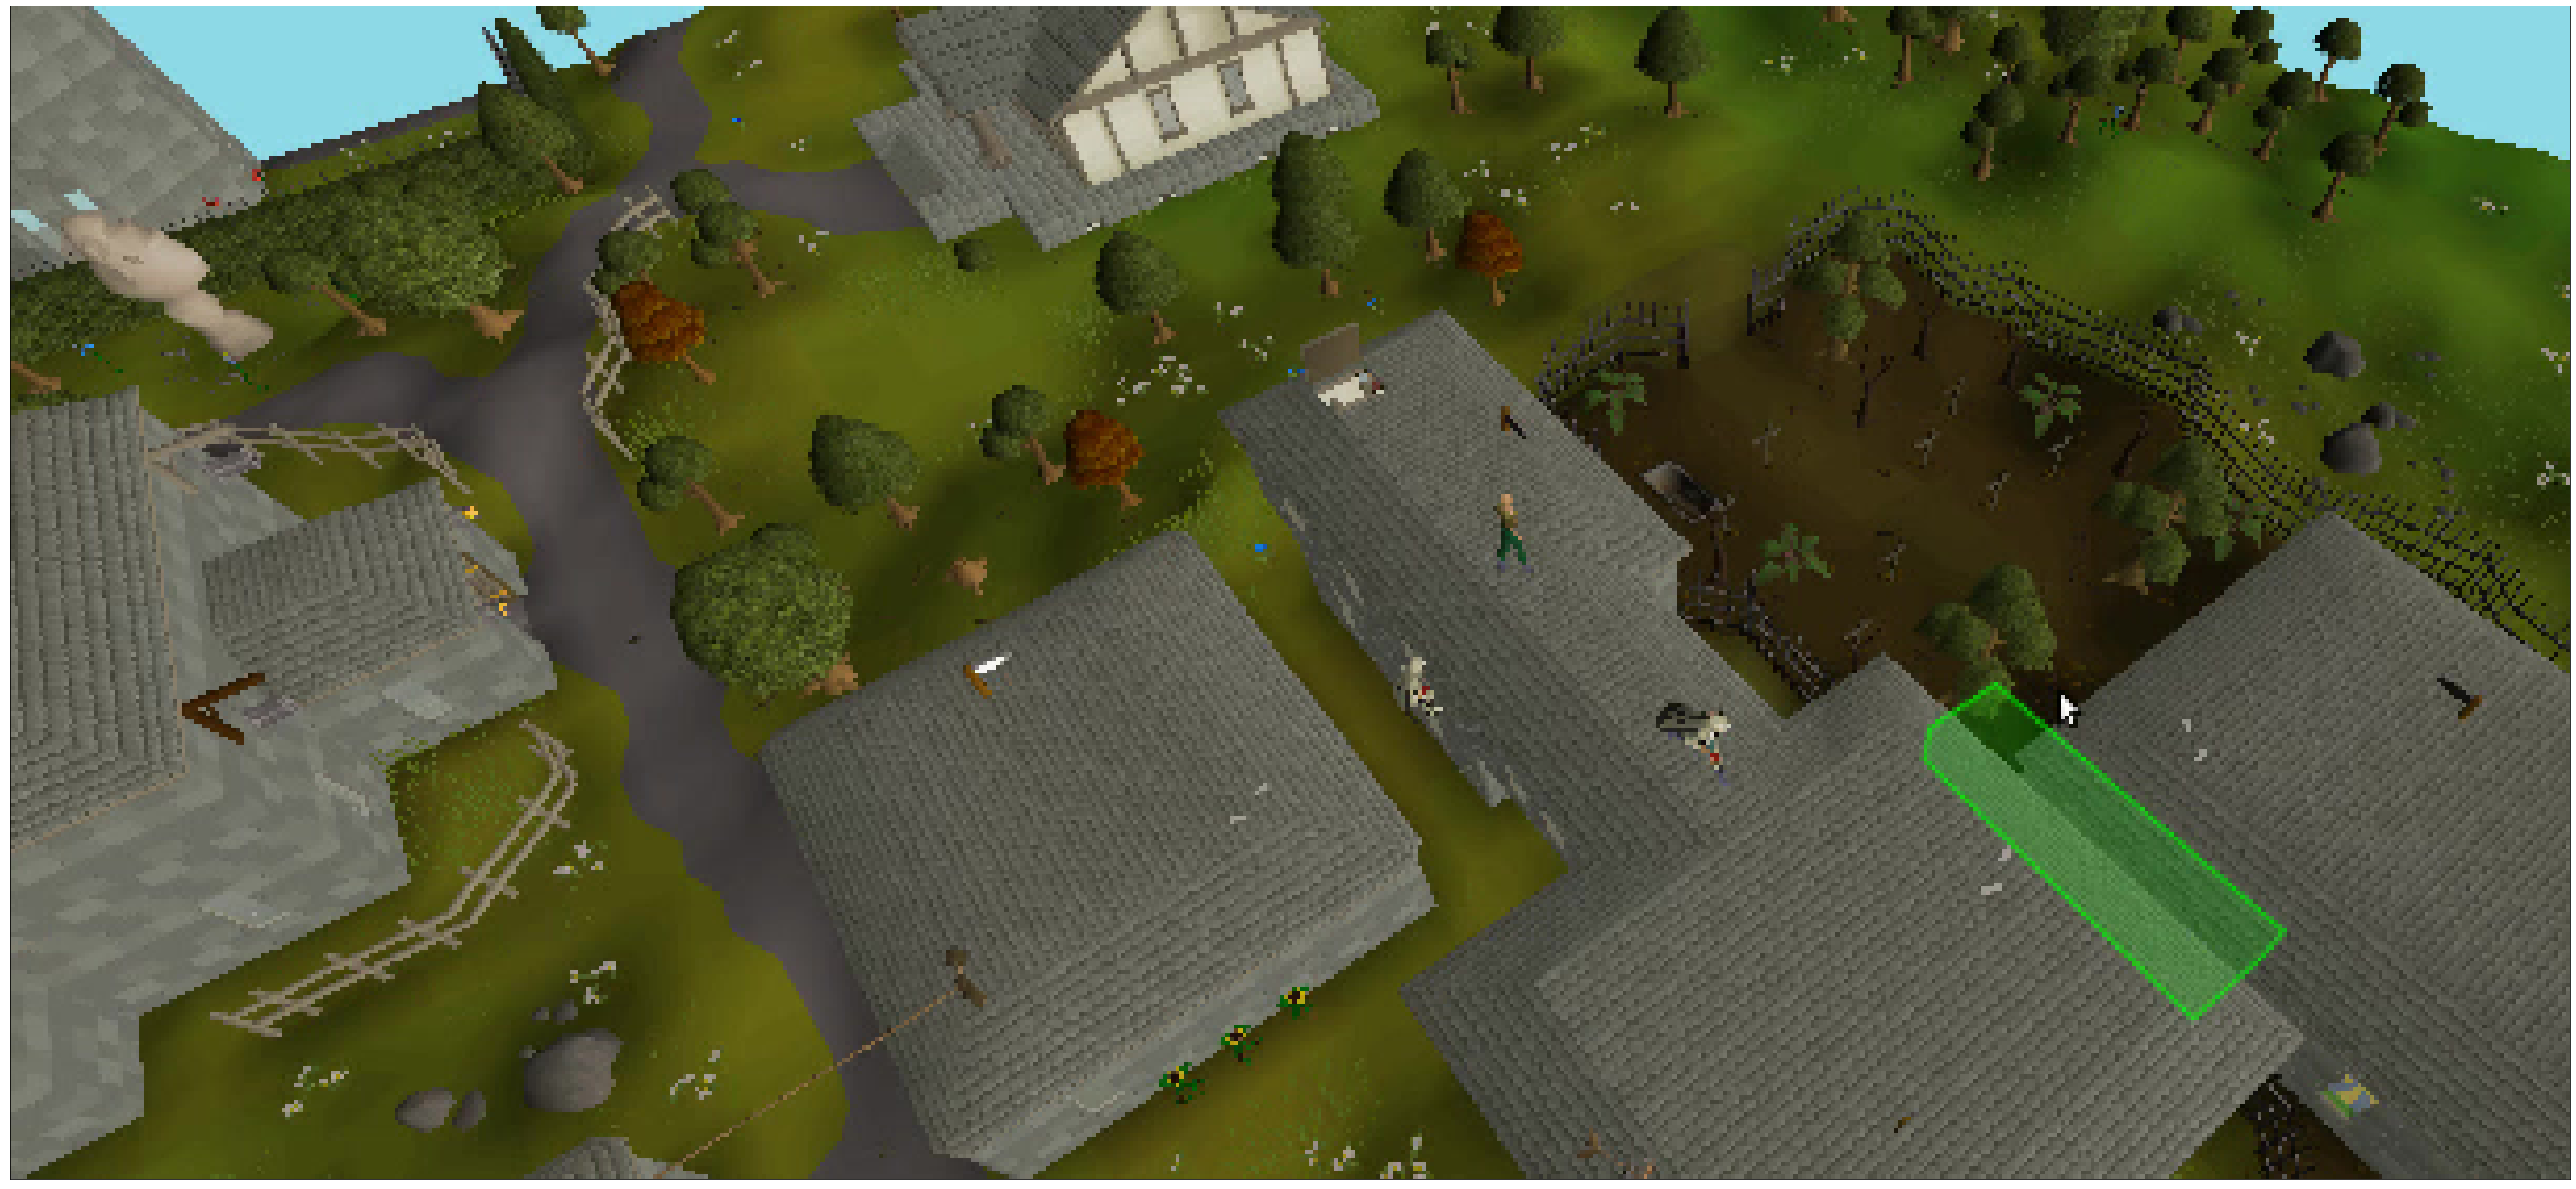

In [8]:
from detectron2.utils.visualizer import ColorMode

im = cv2.imread("./agility_data/video_frames/ezgif-frame-003.jpg", 1)
outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
v = Visualizer(im[:, :, ::-1],
                metadata=detectron2.data.catalog.Metadata(name='balloon_train', thing_classes=['staging', 'obstacle']), 
                scale=0.5, 
#                 instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(50,50))
plt.imshow(out.get_image())
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
plt.show()


In [9]:
out.get_image().shape

(281, 613, 3)

In [11]:
outputs

{'instances': Instances(num_instances=0, image_height=562, image_width=1226, fields=[pred_boxes: Boxes(tensor([], device='cuda:0', size=(0, 4))), scores: tensor([], device='cuda:0'), pred_classes: tensor([], device='cuda:0', dtype=torch.int64), pred_masks: tensor([], device='cuda:0', size=(0, 562, 1226), dtype=torch.bool)])}

In [10]:
cfg.MODEL.WEIGHTS

'./agility_model.pth'

In [11]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file('COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml'))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5 # Set threshold for this model
cfg.MODEL.WEIGHTS = './agility_model.pth' # Set path model .pth
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2
predictor = DefaultPredictor(cfg)

In [12]:
im = cv2.imread("./agility_data/video_frames/ezgif-frame-003.jpg", 1)
outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format

In [19]:
outputs

{'instances': Instances(num_instances=1, image_height=562, image_width=1226, fields=[pred_boxes: Boxes(tensor([[ 915.9067,  314.9055, 1091.6863,  494.3800]], device='cuda:0')), scores: tensor([0.9317], device='cuda:0'), pred_classes: tensor([1], device='cuda:0'), pred_masks: tensor([[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]], device='cuda:0')])}

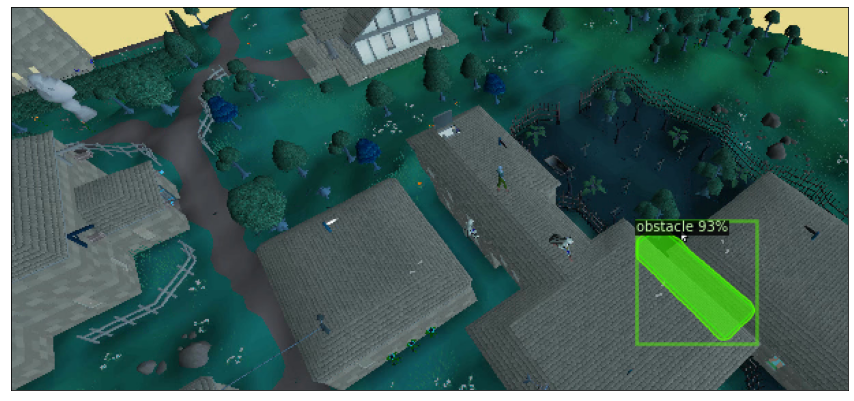

In [14]:


v = MyVisualizer(
                # im,
                im[:, :, ::-1],
                metadata=detectron2.data.catalog.Metadata(name='balloon_train', thing_classes=['staging', 'obstacle']), 
                scale=0.5, 
#                 instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(15,15))
plt.imshow(out.get_image())
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
plt.show()


In [15]:
plt.figure(figsize=(15,15))
plt.imshow(out.get_image())
plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
plt.show()

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val',)
  TRAIN: ('coco_2017_train',)
GLOBAL:
  HACK: 1.0
INPUT:
  CROP:
    ENABLED: False
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  FORMAT: BGR
  MASK_FORMAT: polygon
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (640, 672, 704, 736, 768, 800)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32], [64], [128], [256], [512]]
  BACKBONE:
    FREEZE_AT: 2
    NAME: build_resnet_fpn_backbone
  DEVICE: cuda
  FPN:
    FUSE_TYPE: sum
    IN_FEATURES: ['res2', 